In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt


sns.set_theme(
    style='whitegrid',
    palette='deep',
    font_scale=1.2,
    rc={'figure.figsize': (12,6)}
)

In [3]:
df_games = pd.read_csv('appstore_games.csv')

In [4]:
df_games.head()

,URL,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,NaN,"Join over 21,000,000 of our fans and download ...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",15853568.0,Games,"Games, Strategy, Puzzle",11/07/2008,30/05/2017
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,NaN,"The classic game of Reversi, also known as Oth...",Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",11/07/2008,17/05/2018
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,NaN,Play the classic strategy game Othello (also k...,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",11/07/2008,5/09/2017
3,https://apps.apple.com/us/app/sudoku-free/id28...,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,190394.0,0.00,NaN,"Top 100 free app for over a year.\nRated ""Best...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",21552128.0,Games,"Games, Strategy, Puzzle",23/07/2008,30/05/2017
4,https://apps.apple.com/us/app/senet-deluxe/id2...,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.5,28.0,2.99,NaN,"""Senet Deluxe - The Ancient Game of Life and A...",RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU...",34689024.0,Games,"Games, Strategy, Board, Education",18/07/2008,22/07/2018


In [5]:
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 17007 entries, 0 to 17006
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   URL                           17007 non-null  str    
 1   ID                            17007 non-null  int64  
 2   Name                          17007 non-null  str    
 3   Subtitle                      5261 non-null   str    
 4   Icon URL                      17007 non-null  str    
 5   Average User Rating           7561 non-null   float64
 6   User Rating Count             7561 non-null   float64
 7   Price                         16983 non-null  float64
 8   In-app Purchases              7683 non-null   str    
 9   Description                   17007 non-null  str    
 10  Developer                     17007 non-null  str    
 11  Age Rating                    17007 non-null  str    
 12  Languages                     16947 non-null  str    
 13  Size        

In [6]:
df_games['In-app Purchases'].value_counts().head(20)


In-app Purchases
0.99                                                          943
2.99                                                          608
1.99                                                          560
4.99                                                          154
0.99, 0.99                                                    140
3.99                                                           83
1.99, 0.99                                                     58
0.99, 0.99, 0.99                                               51
0.99, 1.99                                                     48
1.99, 1.99                                                     38
9.99                                                           34
0.99, 2.99                                                     33
0.99, 1.99, 2.99                                               28
5.99                                                           27
0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99 

In [7]:
def myf(x): 
    if pd.isna(x):
        return []
    else:
        spl = str(x).split(',')
        numbers = [] 

        for i in spl:
            numbers.append(float(i.strip()))

        return numbers

In [8]:
df_games['In-app Purchases'] = df_games['In-app Purchases'].apply(myf)

In [9]:
df_games['iap_count'] = df_games['In-app Purchases'].apply(len)

Most Common Words in Game Names

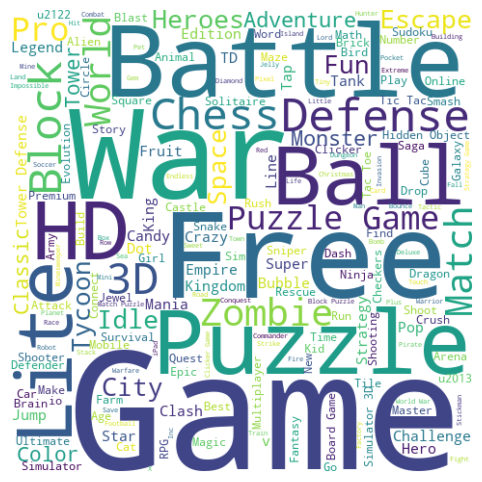

In [10]:
text = ' '.join(df_games['Name'].astype(str))

wordcloud = WordCloud(width=480, height=480, margin=0, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

Most Common Words in Game Subtitle

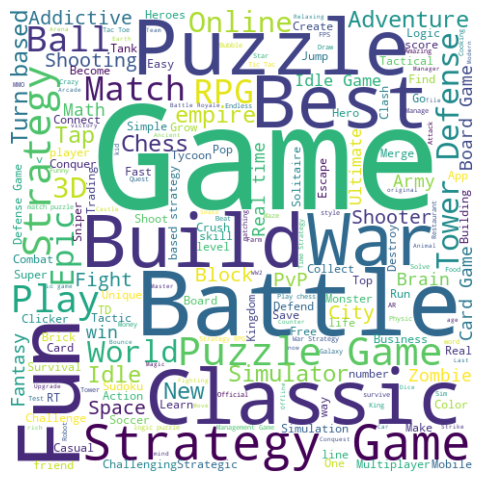

In [11]:
text = ' '.join(df_games['Subtitle'].dropna().astype(str))

wordcloud = WordCloud(width=480, height=480, margin=0, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

Top-Rated Games with High User Engagement

In [12]:
df_games.describe()

,ID,Average User Rating,User Rating Count,Price,Size,iap_count
count,1.700700e+04,7561.000000,7.561000e+03,16983.000000,1.700600e+04,17007.000000
mean,1.059614e+09,4.060905,3.306531e+03,0.813419,1.157064e+08,2.042747
std,2.999676e+08,0.751428,4.232256e+04,7.835732,2.036477e+08,3.257898
min,2.849214e+08,1.000000,5.000000e+00,0.000000,5.132800e+04,0.000000
25%,8.996543e+08,3.500000,1.200000e+01,0.000000,2.295014e+07,0.000000
50%,1.112286e+09,4.500000,4.600000e+01,0.000000,5.676895e+07,0.000000
75%,1.286983e+09,4.500000,3.090000e+02,0.000000,1.330271e+08,3.000000
max,1.475077e+09,5.000000,3.032734e+06,179.990000,4.005591e+09,17.000000


In [13]:
df_games['Genres_list'] = df_games['Genres'].str.split(', ')

genre_counts = (
    df_games['Genres_list']
    .explode()
    .dropna()
    .value_counts()
     .drop('Games')
     .drop('Strategy')
)

genre_counts

Genres_list
Entertainment             7991
Puzzle                    3960
Simulation                2143
Action                    2012
Board                     1722
Casual                    1697
Role Playing              1126
Education                  951
Adventure                  836
Family                     773
Sports                     739
Card                       674
Trivia                     289
Lifestyle                  220
Utilities                  177
Racing                     129
Social Networking          126
Word                       125
Music                      112
Travel                      93
Reference                   84
Casino                      75
Productivity                62
Food & Drink                57
Finance                     51
Business                    45
Books                       38
Health & Fitness            34
Stickers                    31
Photo & Video               25
Gaming                      25
News                       

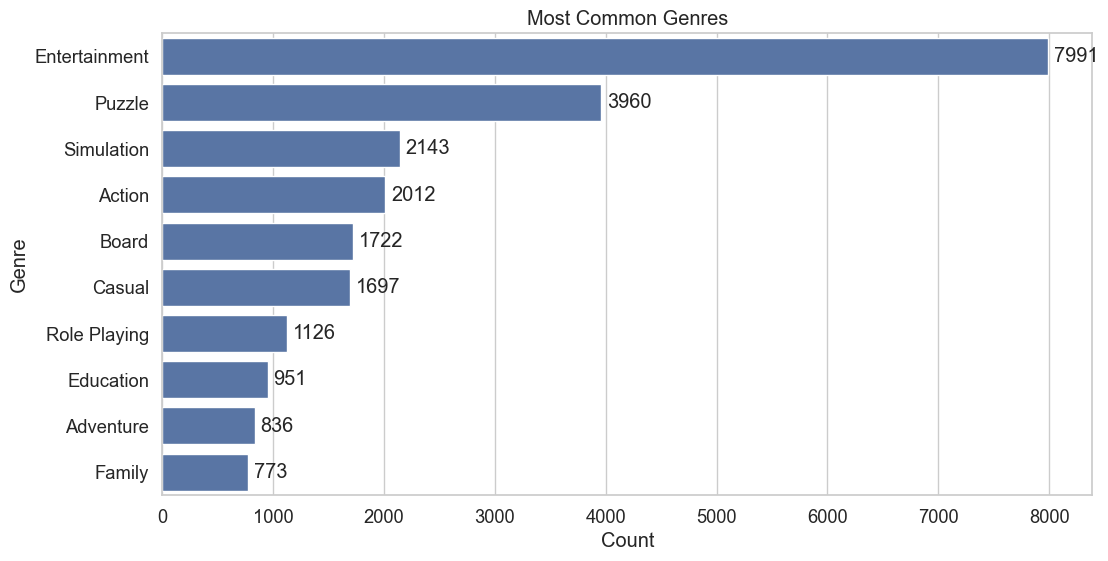

In [14]:
genre_counts10 = genre_counts[0:10]

sns.barplot(
    x=genre_counts10.values,
    y=genre_counts10.index
)

plt.title('Most Common Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

for i, v in enumerate(genre_counts10.values):
    plt.text(v + 50, i, str(v), va='center')

plt.show()

Top Genres by Average User Rating

In [15]:
avg_rating = (
    df_games
    .explode('Genres_list')
    .groupby('Genres_list') ['Average User Rating']
    .mean()
    .loc[genre_counts.index]
    .sort_values(ascending=False)
)[0:10]
avg_rating

Genres_list
Magazines & Newspapers    5.000000
Shopping                  4.500000
Health & Fitness          4.333333
Photo & Video             4.300000
Emoji & Expressions       4.250000
News                      4.222222
Travel                    4.216216
Casual                    4.203985
Lifestyle                 4.197531
Food & Drink              4.180000
Name: Average User Rating, dtype: float64

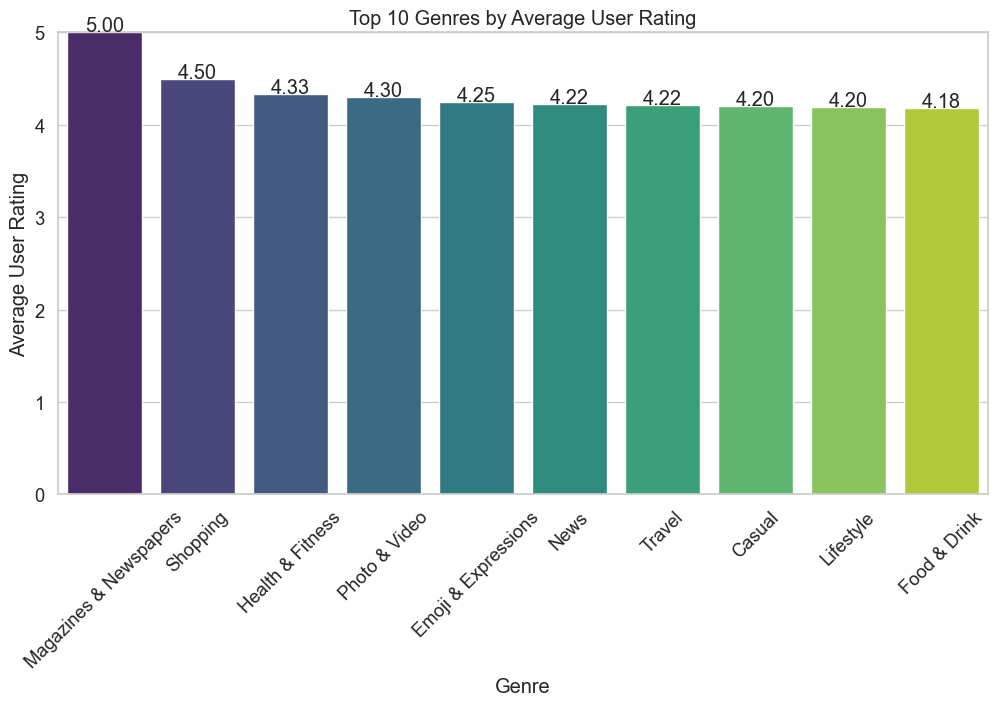

In [46]:
sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    hue=avg_rating.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Genres by Average User Rating')
plt.xlabel('Genre')
plt.ylabel('Average User Rating')

for i, v in enumerate(avg_rating.values):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.ylim(0, 5)

plt.xticks(rotation=45)

plt.show()

Top Genres by Average User Rating

In [17]:
avg_users = (
    df_games
    .explode('Genres_list')
    .groupby('Genres_list') ['User Rating Count']
    .mean()
    .loc[genre_counts.index]
    .sort_values(ascending=False)
)[0:10]
avg_users.astype(int)

Genres_list
Health & Fitness     29669
Navigation           13741
Action                9620
Finance               8072
Social Networking     4330
Entertainment         4109
Role Playing          3942
Simulation            3860
Adventure             3064
Sports                2977
Name: User Rating Count, dtype: int64

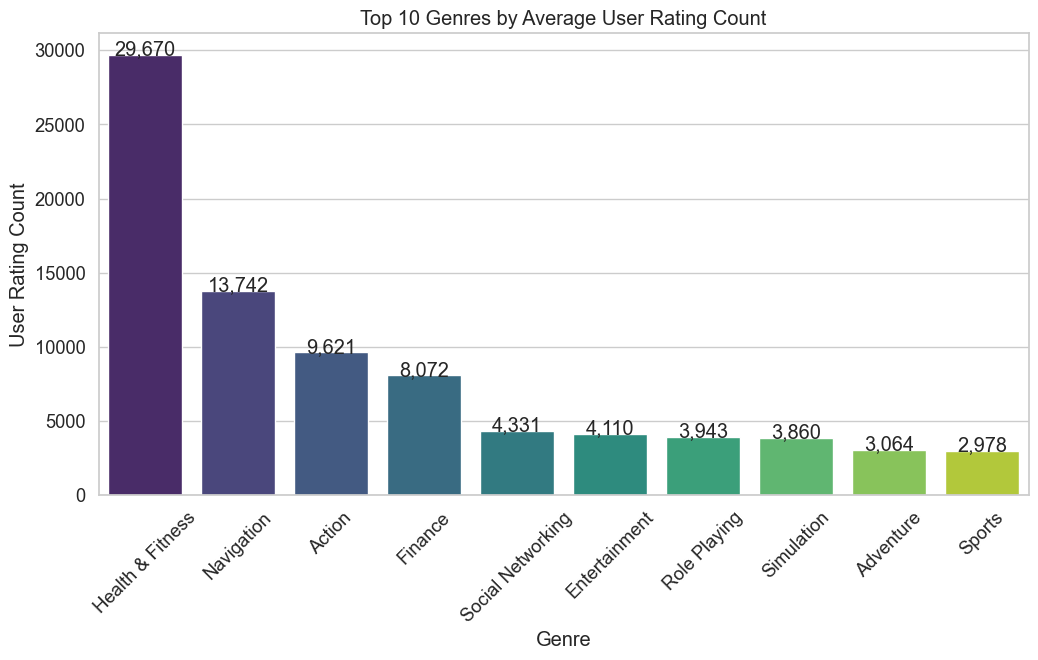

In [48]:
sns.barplot(
    x=avg_users.index,
    y=avg_users.values,
    hue=avg_users.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Genres by Average User Rating Count')
plt.xlabel('Genre')
plt.ylabel('User Rating Count')

for i, v in enumerate(avg_users.values):
    plt.text(i, v + 0.1, f'{v:,.0f}', ha='center')

plt.xticks(rotation=45)

plt.show()

Number of Games by Size

In [19]:
df_games['Size_MB'] = df_games['Size'] / (1024 * 1024)

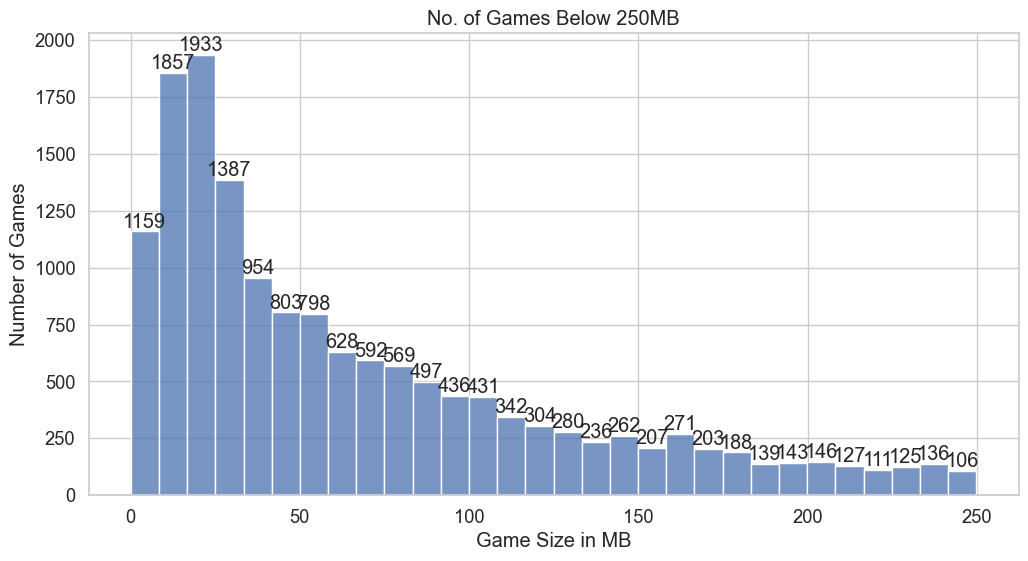

In [20]:
ax = sns.histplot(
    df_games[(df_games['Size_MB'] <= 250)]['Size_MB'],
    bins=30
)

plt.title('No. of Games Below 250MB')
plt.xlabel('Game Size in MB')
plt.ylabel('Number of Games')

for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

plt.show()

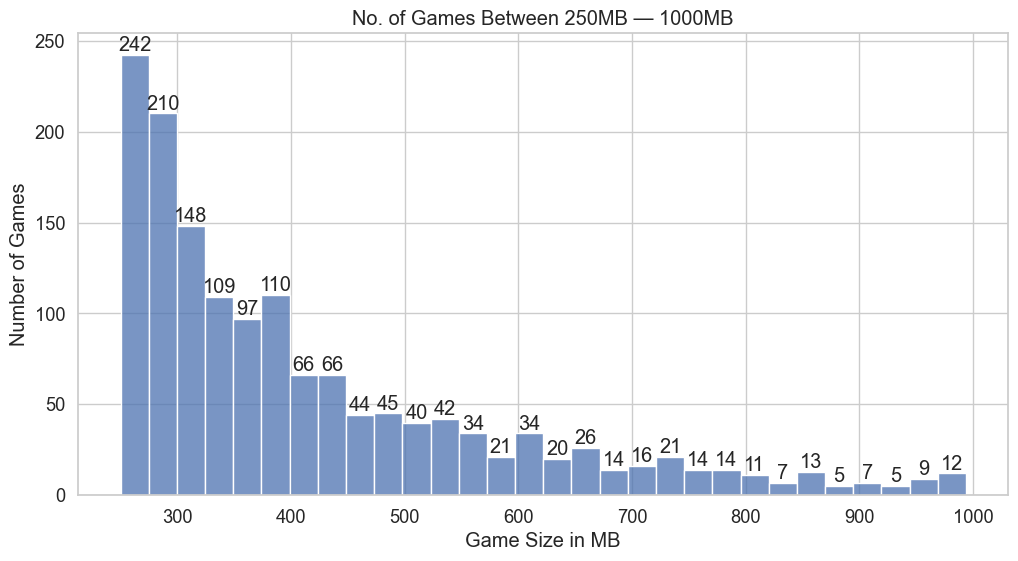

In [21]:
ax = sns.histplot(
    df_games[(df_games['Size_MB'] > 250) & (df_games['Size_MB'] <= 1000)]['Size_MB'],
    bins=30
)

plt.title('No. of Games Between 250MB — 1000MB')
plt.xlabel('Game Size in MB')
plt.ylabel('Number of Games')

for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

plt.show()

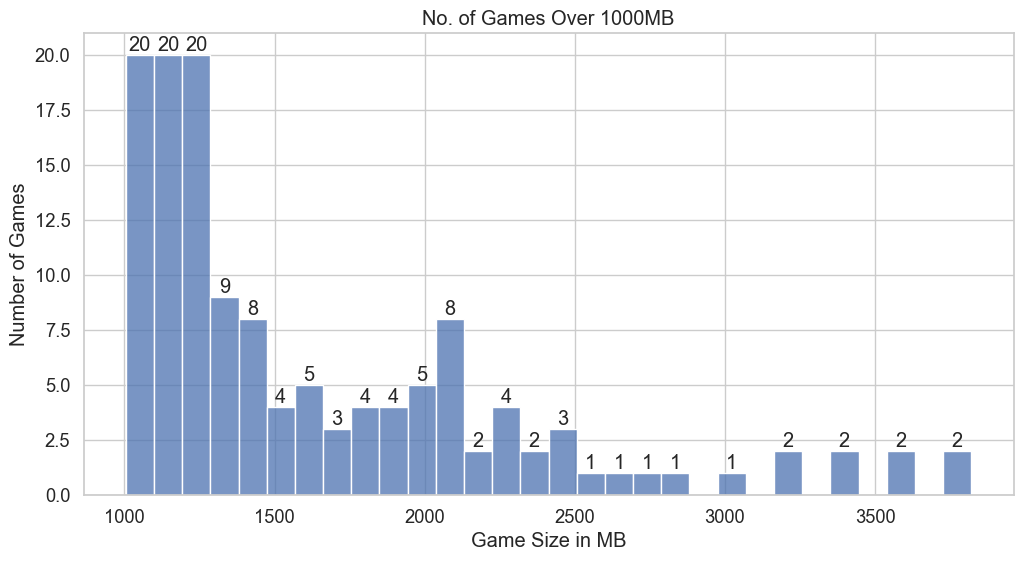

In [22]:
ax = sns.histplot(
    df_games[(df_games['Size_MB'] > 1000)]['Size_MB'],
    bins=30
)

plt.title('No. of Games Over 1000MB')
plt.xlabel('Game Size in MB')
plt.ylabel('Number of Games')

# подписи
for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

plt.show()

User Engagement by Update Recency

In [24]:
df_games['Current Version Release Date']

0        30/05/2017
1        17/05/2018
2         5/09/2017
3        30/05/2017
4        22/07/2018
            ...    
17002    30/07/2019
17003     1/08/2019
17004     3/08/2019
17005     1/08/2019
17006     2/08/2019
Name: Current Version Release Date, Length: 17007, dtype: str

In [25]:
df_games['Current Version Release Date'] = pd.to_datetime(
    df_games['Current Version Release Date'],
    dayfirst=True
)

df_games['Days Since Update'] = (
    pd.Timestamp.today() - df_games['Current Version Release Date']
).dt.days

In [26]:
Recent = (df_games['Days Since Update'] <= 2600)
Moderate = (df_games['Days Since Update'] > 2600) & (df_games['Days Since Update'] <= 3500)
Old = (df_games['Days Since Update'] > 3500)

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/3610676146.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


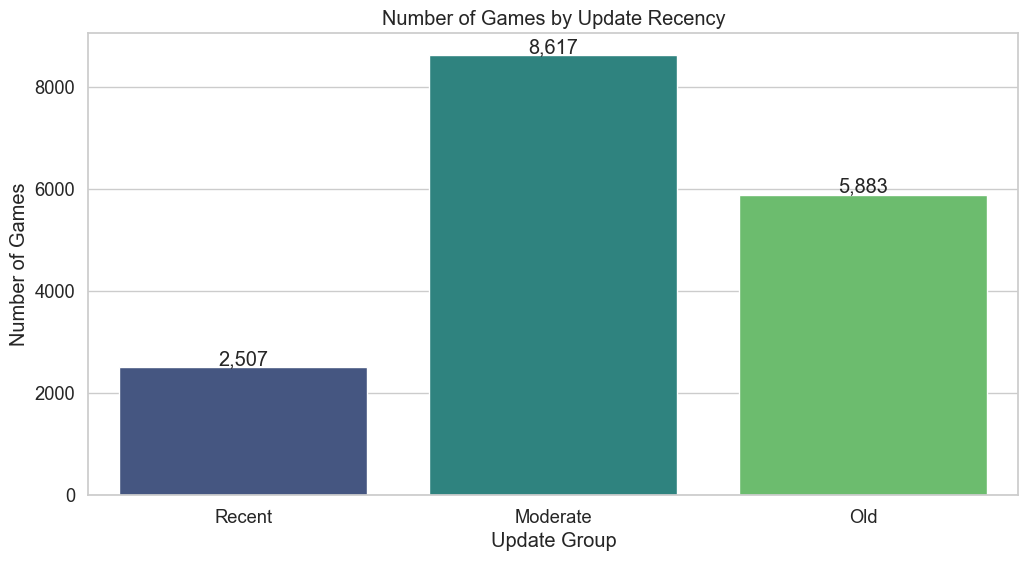

In [27]:
update_counts = {
    'Recent': Recent.sum(),
    'Moderate': Moderate.sum(),
    'Old': Old.sum()
}

sns.barplot(
    x=list(update_counts.keys()),
    y=list(update_counts.values()),
    palette='viridis'
)

plt.title('Number of Games by Update Recency')
plt.xlabel('Update Group')
plt.ylabel('Number of Games')

# подписи
for i, v in enumerate(update_counts.values()):
    plt.text(i, v + 50, f'{v:,}', ha='center')

plt.show()

In [28]:
df_games['User Rating Count'].describe()

count    7.561000e+03
mean     3.306531e+03
std      4.232256e+04
min      5.000000e+00
25%      1.200000e+01
50%      4.600000e+01
75%      3.090000e+02
max      3.032734e+06
Name: User Rating Count, dtype: float64

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/3076989953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


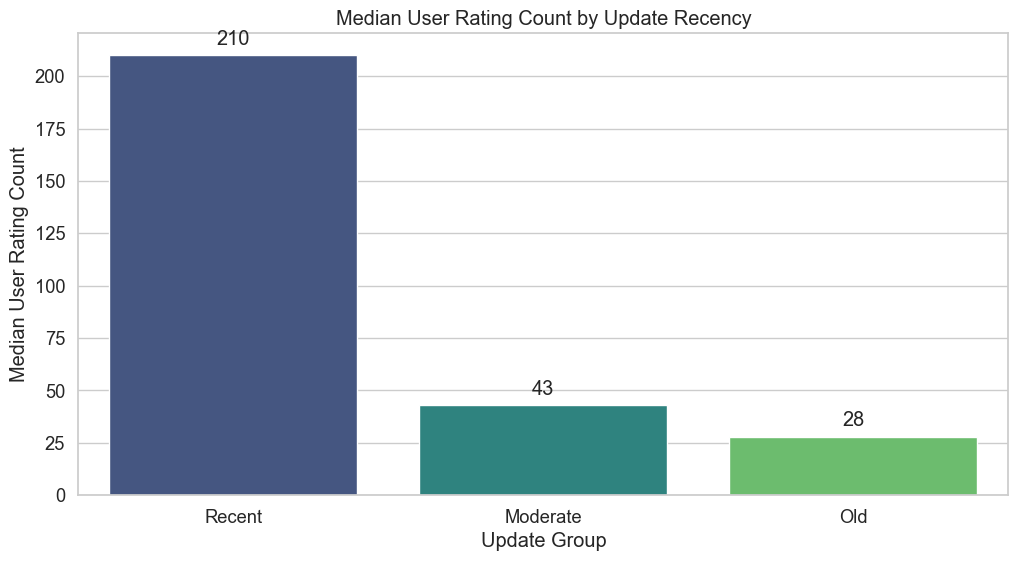

In [45]:
update_users = {
    'Recent': df_games[Recent]['User Rating Count'].median(),
    'Moderate': df_games[Moderate]['User Rating Count'].median(),
    'Old': df_games[Old]['User Rating Count'].median()
}

sns.barplot(
    x=list(update_users.keys()),
    y=list(update_users.values()),
    palette='viridis'
)

plt.title('Median User Rating Count by Update Recency')
plt.xlabel('Update Group')
plt.ylabel('Median User Rating Count')

# подписи
for i, v in enumerate(update_users.values()):
    plt.text(i, v + 5, f'{int(v):,}', ha='center')

plt.show()

Price vs User Rating Count

In [30]:
free = (df_games['Price'] == 0)
cheap = ((df_games['Price'] > 0 )& (df_games['Price'] <= 10))
mid_range = ((df_games['Price'] > 10 )& (df_games['Price'] <= 20))
premium = (df_games['Price'] > 20)

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/3857197990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


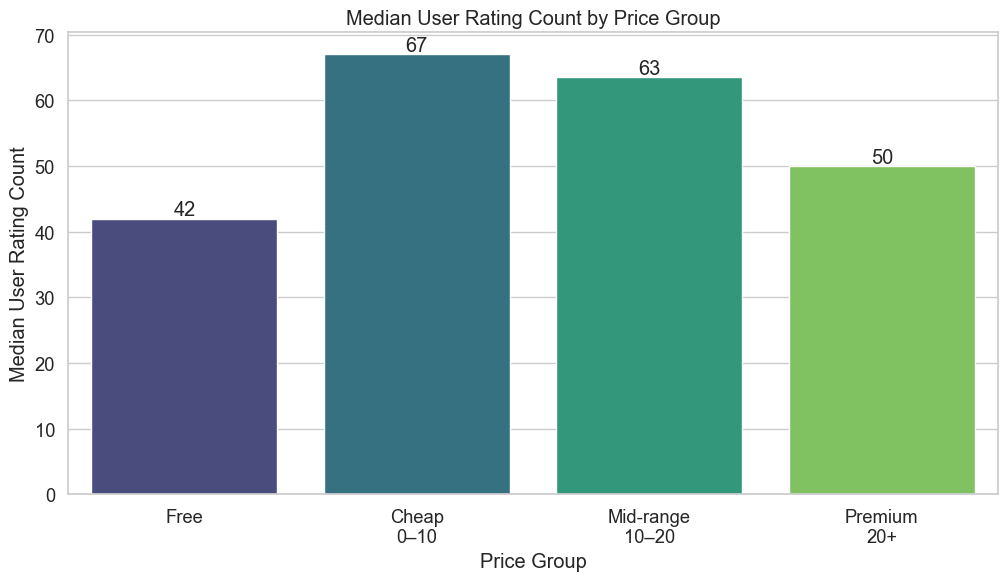

In [44]:
price_users = {
    'Free': df_games[free]['User Rating Count'].median(),
    'Cheap\n0–10': df_games[cheap]['User Rating Count'].median(),
    'Mid-range\n10–20': df_games[mid_range]['User Rating Count'].median(),
    'Premium\n20+': df_games[premium]['User Rating Count'].median()
}

sns.barplot(
    x=list(price_users.keys()),
    y=list(price_users.values()),
    palette='viridis'
)

plt.title('Median User Rating Count by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Median User Rating Count')

for i, v in enumerate(price_users.values()):
    plt.text(i, v + 0.5, f'{int(v):,}', ha='center')

plt.show()

Price vs Average User Rating

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/88442278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


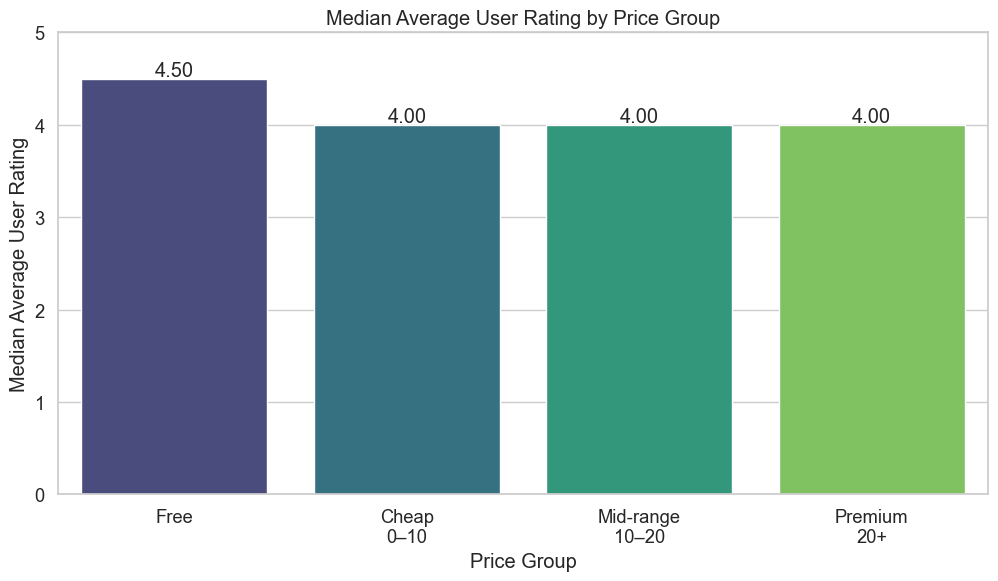

In [32]:
price_users = {
    'Free': df_games[free]['Average User Rating'].median(),
    'Cheap\n0–10': df_games[cheap]['Average User Rating'].median(),
    'Mid-range\n10–20': df_games[mid_range]['Average User Rating'].median(),
    'Premium\n20+': df_games[premium]['Average User Rating'].median()
}

sns.barplot(
    x=list(price_users.keys()),
    y=list(price_users.values()),
    palette='viridis'
)

plt.title('Median Average User Rating by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Median Average User Rating')

for i, v in enumerate(price_users.values()):
    plt.text(i, v + 0.03, f'{v:.2f}', ha='center')

plt.ylim(0, 5)

plt.show()

Monetization potential by Genre

In [34]:
df_games['SUM_IAP'] = df_games['In-app Purchases'].apply(sum)

In [35]:
avg_IAP = (
    df_games
    .explode('Genres_list')
    .groupby('Genres_list') ['SUM_IAP']
    .median()
    .sort_values(ascending=False)
)[0:10]

avg_IAP

Genres_list
Role Playing              22.910
Medical                    4.990
Magazines & Newspapers     3.990
Travel                     1.990
Simulation                 1.990
Food & Drink               1.990
Social Networking          1.985
Family                     0.990
Racing                     0.990
Music                      0.990
Name: SUM_IAP, dtype: float64

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/4167552982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


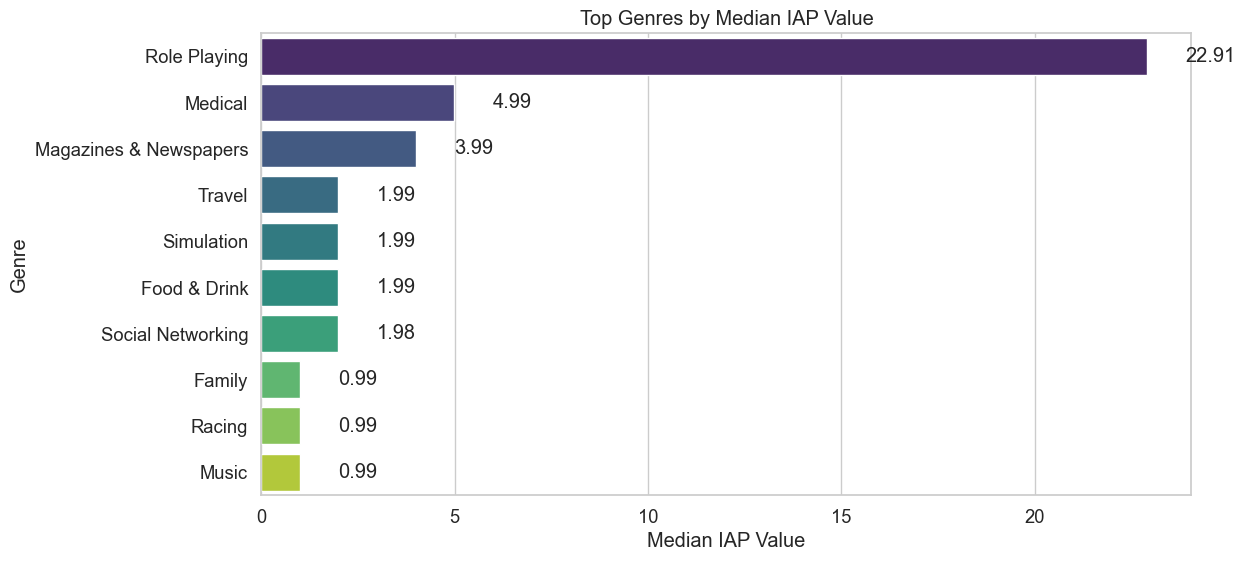

In [36]:
avg_IAP10 = avg_IAP[0:10]

sns.barplot(
    x=avg_IAP10.values,
    y=avg_IAP10.index,
    palette='viridis'
)

plt.title('Top Genres by Median IAP Value')
plt.xlabel('Median IAP Value')
plt.ylabel('Genre')

for i, v in enumerate(avg_IAP10.values):
    plt.text(v + 1, i, f'{v:.2f}', va='center')

plt.show()

In [37]:
df_games['Developer'].value_counts()[0:10]

Developer
Tapps Tecnologia da Informa\xe7\xe3o Ltda.    123
Vikash Patel                                  107
Netsummit Marketing, Inc.                      95
GabySoft                                       85
NetSummit Enterprises, Inc.                    77
Andrew Kudrin                                  62
MmpApps Corp.                                  61
Domyung Kim                                    57
Amy Prizer                                     46
Detention Apps                                 42
Name: count, dtype: int64

/var/folders/cv/b1w8syyx55v6x9ttzq6gbh0c0000gn/T/ipykernel_45591/42202171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


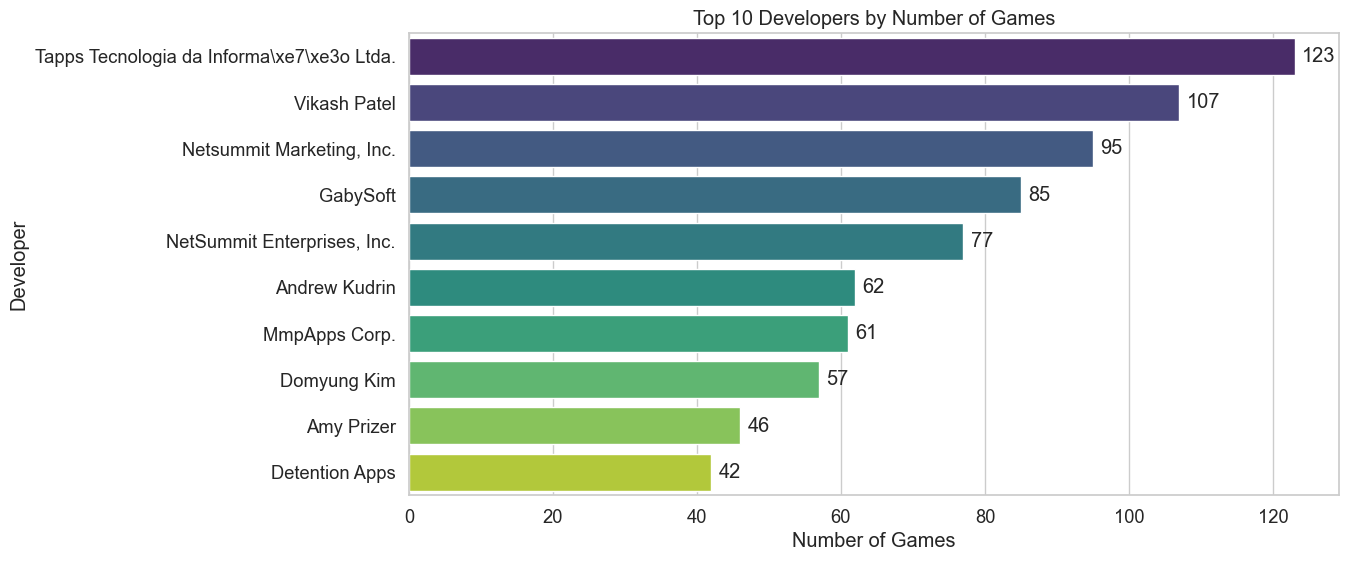

In [38]:
top_developers = df_games['Developer'].value_counts()[0:10]

sns.barplot(
    x=top_developers.values,
    y=top_developers.index,
    palette='viridis'
)

plt.title('Top 10 Developers by Number of Games')
plt.xlabel('Number of Games')
plt.ylabel('Developer')

# подписи
for i, v in enumerate(top_developers.values):
    plt.text(v + 1, i, str(v), va='center')

plt.show()